# Esercizi

## 4. Rispondere alle domande

### Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe

### - Mostrami le vendite maggiori di 10

### - Mostrami i dati del 2018

### - Mostrami le vendite maggiori di 13 e l'anno è il 2018

### - Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

### - Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

### - Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading data

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [2]:
# vendite maggiori di 10

In [3]:
sales.query("sales > 10")

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
3,Roman,12,2018
7,Alaina,15,2020


In [4]:
# dati del 2018

In [5]:
sales.query("year == 2018")

,employee,sales,year
0,Katrina,14,2018
3,Roman,12,2018


In [6]:
# vendite maggiori di 13 e l'anno è il 2018

sales.query("sales > 13 & year == 2018")

,employee,sales,year
0,Katrina,14,2018


In [7]:
# tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018
sales.query("not(sales > 13 & year == 2018)")

,employee,sales,year
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [8]:
# dati dove le vendite divise per 3 sono maggiori di 3

sales.query("sales / 3 > 3")

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
3,Roman,12,2018
7,Alaina,15,2020


In [9]:
# dipendenti i cui nomi sono alfabeticamente dopo la J

sales.query('employee > "J"')

,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


## 5. Analisi di un dataset di video giochi

### 1. Quanti videogiochi sono stati pubblicati
### 2. Quali sono i generi più popolari? Mostralo con un bar plot
### 3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
### 4. Prova a riprodurre questo plot

In [10]:
#load data

url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
# Quanti videogiochi sono stati pubblicati

df.index.size

16598

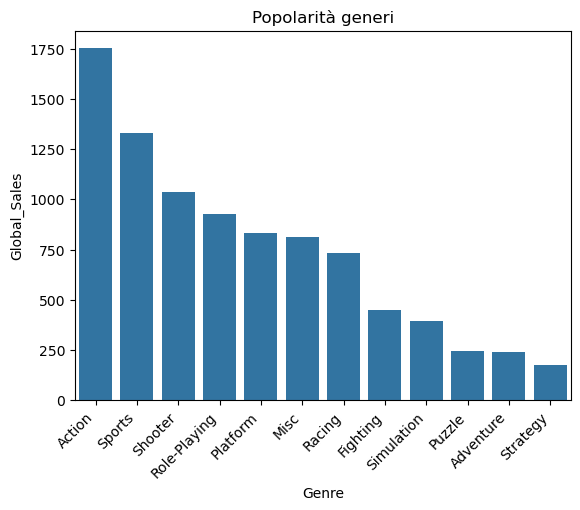

In [12]:
# Quali sono i generi più popolari? Mostralo con un bar plot

genre = df.groupby("Genre")["Global_Sales"].sum().reset_index().sort_values("Global_Sales", ascending=False)


sns.barplot(data=genre, x="Genre", y="Global_Sales")
plt.title("Popolarità generi")

plt.xticks(rotation=45, ha="right", va="top")

plt.show()

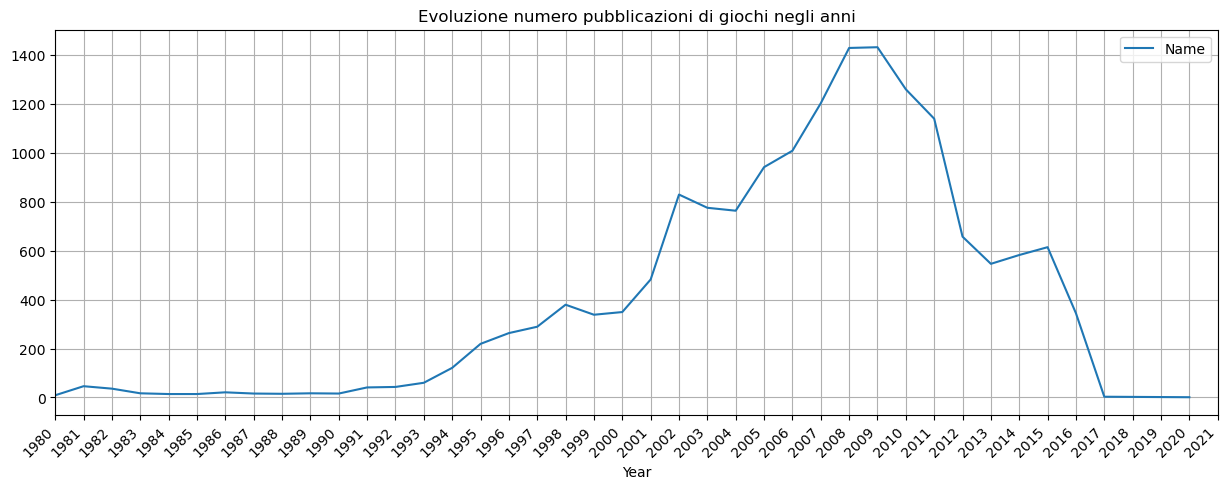

In [21]:
# Plotta l'evoluzione del numero di giochi pubblicati nel tempo

years = df.groupby("Year")["Name"].count().reset_index().sort_values("Year", ascending=True)

years.plot(x="Year", y="Name", figsize=(15, 5))
plt.title("Evoluzione numero pubblicazioni di giochi negli anni")

plt.xlim(1980, 2021)
plt.grid()
plt.xticks(range(1980, 2022), rotation=45, ha="right", va="top")

plt.show()


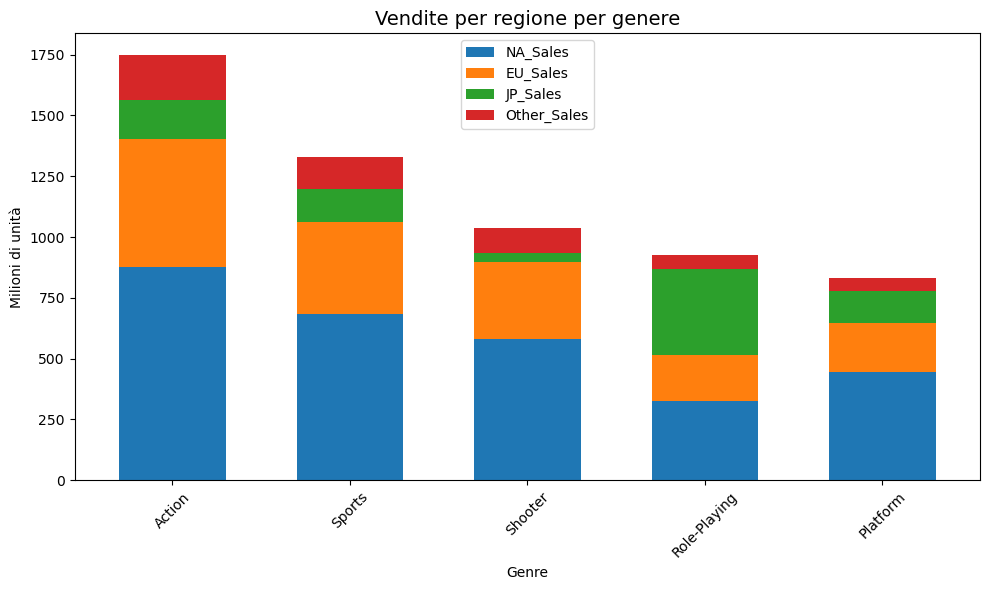

In [44]:
# Replica plot

df.groupby("Genre")



top_genres = df.groupby("Genre")["Global_Sales"].sum().nlargest(5).index
top_genres = top_genres.to_list()

df_filtered = df[df["Genre"].isin(top_genres)]

df_grouped = df_filtered.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum().loc[top_genres]  # mantieni l'ordine dei top 5

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 6))

df_grouped.plot(kind="bar", stacked=True, color=colors, ax=ax, width=0.6)

ax.set_title("Vendite per regione per genere", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Milioni di unità")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper center")

plt.tight_layout()
plt.savefig("vendite_per_genere.png", dpi=150)
plt.show()


